# Capítulo 1 - Introdução

Página 24-39

## Encontrando conectores-chave

Quem é amigo de quem?

In [1]:
# lista de usuarios da rede social para cientistas de dados
users = [
    { "id": 0, "name": "Hero" },
    { "id": 1, "name": "Dunn" },
    { "id": 2, "name": "Sue" },
    { "id": 3, "name": "Chi" },
    { "id": 4, "name": "Thor" },
    { "id": 5, "name": "Clive" },
    { "id": 6, "name": "Hicks" },
    { "id": 7, "name": "Devin" },
    { "id": 8, "name": "Kate" },
    { "id": 9, "name": "Klein" }
]

# lista de amizades
friendships = [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (3, 4),
               (4, 5), (5, 6), (5, 7), (6, 8), (7, 8), (8, 9)]

In [2]:
# adicionar lista de amigos para cada usuario
for u in users:
    u['friends'] = []

for i, j in friendships:
    users[i]['friends'].append(users[j]["id"]) # adiciona j como amigo de i
    users[j]['friends'].append(users[i]["id"]) # adiciona i como amigo de j

users

[{'id': 0, 'name': 'Hero', 'friends': [1, 2]},
 {'id': 1, 'name': 'Dunn', 'friends': [0, 2, 3]},
 {'id': 2, 'name': 'Sue', 'friends': [0, 1, 3]},
 {'id': 3, 'name': 'Chi', 'friends': [1, 2, 4]},
 {'id': 4, 'name': 'Thor', 'friends': [3, 5]},
 {'id': 5, 'name': 'Clive', 'friends': [4, 6, 7]},
 {'id': 6, 'name': 'Hicks', 'friends': [5, 8]},
 {'id': 7, 'name': 'Devin', 'friends': [5, 8]},
 {'id': 8, 'name': 'Kate', 'friends': [6, 7, 9]},
 {'id': 9, 'name': 'Klein', 'friends': [8]}]

In [3]:
# numero medio de conexoes
def number_of_friends(user):
    return len(user['friends'])

num_connections = [number_of_friends(user) for user in users]
print("num_connections:", num_connections)

total_connections = sum(num_connections)
print("total_connections:", total_connections)

num_users = len(users)
print("num_users:", num_users)

avg_connections = total_connections / num_users
print("avg_connections:", avg_connections)

num_connections: [2, 3, 3, 3, 2, 3, 2, 2, 3, 1]
total_connections: 24
num_users: 10
avg_connections: 2.4


In [4]:
# ordena usuarios de acordo com quantidade de amigos
num_friends_by_id = [(user['id'], number_of_friends(user)) for user in users]
print("num_friends_by_id:", num_friends_by_id)

sorted(num_friends_by_id, key=lambda x: x[1], reverse=True)

num_friends_by_id: [(0, 2), (1, 3), (2, 3), (3, 3), (4, 2), (5, 3), (6, 2), (7, 2), (8, 3), (9, 1)]


[(1, 3),
 (2, 3),
 (3, 3),
 (5, 3),
 (8, 3),
 (0, 2),
 (4, 2),
 (6, 2),
 (7, 2),
 (9, 1)]

## _"Cientistas de dados que você talvez conheça"_

In [5]:
# identifica amigos dos amigos
def friends_of_friends_ids_bad(user):
    print(f"IDs de amigos do usuario ({user["id"]}):", user['friends'])
    for friend_id in user['friends']:
        target_user = users[friend_id]
        print(f"target_user ({friend_id}):", target_user['friends'])

    # return None
    return [foaf for friend_id in user['friends'] for foaf in users[friend_id]['friends']]

friends_of_friends_ids_bad(users[0])

IDs de amigos do usuario (0): [1, 2]
target_user (1): [0, 2, 3]
target_user (2): [0, 1, 3]


[0, 2, 3, 0, 1, 3]

In [6]:
from collections import Counter # retorna a frequencia de elementos em um iteravel

print(
    Counter("abracadabra"),
    Counter(["apple", "banana", "apple", "cherry", "banana", "apple"])
)

Counter({'a': 5, 'b': 2, 'r': 2, 'c': 1, 'd': 1}) Counter({'apple': 3, 'banana': 2, 'cherry': 1})


In [7]:
def not_the_same(user, other_user):
    # usuarios com IDs diferentes nao podem ser o mesmo usuario
    return user['id'] != other_user['id']

def not_friends(user, other_user):
    # se um usuario nao esta na lista de amigos do outro, entao eles nao sao amigos
    # print("+++ not_friends", user, other_user)
    return all(not_the_same(users[friend_id], other_user) for friend_id in user['friends'])

def friends_of_friends_ids(user):
    print(user['friends'])
    # for friend_id in user['friends']:
    #     print("friend_id", friend_id)
    #     # for foaf_id in users[friend_id]['friends']:
    #     #     print("friend", foaf_id)
    #     #     print(users[foaf_id])
    #     #     # print(not_friends(user, users[foaf_id]))
    #     # # print("not_the_same", not_the_same(user, friend))
    #     # # print("not_friends", not_friends(user, friend))

    # # return None
    friends_of_friends = [
        users[foaf_id]#['id']
        for friend_id in user['friends']
        for foaf_id in users[friend_id]['friends']
          if not_the_same(user, users[foaf_id])
            and not_friends(user, users[foaf_id])
        ]
    print("\nfriends_of_friends:")
    for friend in friends_of_friends:
        print(friend)

    return Counter([friend['id'] for friend in friends_of_friends])

friends_of_friends_ids(users[3])
# procurando entre os amigos dos amigos de '3', vemos que ele:
# - possui 2 amigos em comum com '0'
# - possui 1 amigo em comum com '5'

[1, 2, 4]

friends_of_friends:
{'id': 0, 'name': 'Hero', 'friends': [1, 2]}
{'id': 0, 'name': 'Hero', 'friends': [1, 2]}
{'id': 5, 'name': 'Clive', 'friends': [4, 6, 7]}


Counter({0: 2, 5: 1})

In [8]:
interests = [
    (0, "Hadoop"), (0, "Big Data"), (0, "HBase"), (0, "Java"),
    (0, "Spark"), (0, "Storm"), (0, "Cassandra"),
    (1, "NoSQL"), (1, "MongoDB"), (1, "Cassandra"), (1, "HBase"),
    (1, "Postgres"), (2, "Python"), (2, "scikit-learn"), (2, "scipy"),
    (2, "numpy"), (2, "statsmodels"), (2, "pandas"), (3, "R"), (3, "Python"),
    (3, "statistics"), (3, "regression"), (3, "probability"),
    (4, "machine learning"), (4, "regression"), (4, "decision trees"),
    (4, "libsvm"), (5, "Python"), (5, "R"), (5, "Java"), (5, "C++"),
    (5, "Haskell"), (5, "programming languages"), (6, "statistics"),
    (6, "probability"), (6, "mathematics"), (6, "theory"),
    (7, "machine learning"), (7, "scikit-learn"), (7, "Mahout"),
    (7, "neural networks"), (8, "neural networks"), (8, "deep learning"),
    (8, "Big Data"), (8, "artificial intelligence"), (9, "Hadoop"),
    (9, "Java"), (9, "MapReduce"), (9, "Big Data")
]

In [9]:
from collections import defaultdict

# lista de interesses por usuario
user_ids_by_interest = defaultdict(list)
for user_id, interest in interests:
    user_ids_by_interest[interest].append(user_id)

user_ids_by_interest

defaultdict(list,
            {'Hadoop': [0, 9],
             'Big Data': [0, 8, 9],
             'HBase': [0, 1],
             'Java': [0, 5, 9],
             'Spark': [0],
             'Storm': [0],
             'Cassandra': [0, 1],
             'NoSQL': [1],
             'MongoDB': [1],
             'Postgres': [1],
             'Python': [2, 3, 5],
             'scikit-learn': [2, 7],
             'scipy': [2],
             'numpy': [2],
             'statsmodels': [2],
             'pandas': [2],
             'R': [3, 5],
             'statistics': [3, 6],
             'regression': [3, 4],
             'probability': [3, 6],
             'machine learning': [4, 7],
             'decision trees': [4],
             'libsvm': [4],
             'C++': [5],
             'Haskell': [5],
             'programming languages': [5],
             'mathematics': [6],
             'theory': [6],
             'Mahout': [7],
             'neural networks': [7, 8],
             'deep learning': 

In [10]:
# lista de usuarios por interesse
interests_by_user_id = defaultdict(list)
for user_id, interest in interests:
    interests_by_user_id[user_id].append(interest)

interests_by_user_id

defaultdict(list,
            {0: ['Hadoop',
              'Big Data',
              'HBase',
              'Java',
              'Spark',
              'Storm',
              'Cassandra'],
             1: ['NoSQL', 'MongoDB', 'Cassandra', 'HBase', 'Postgres'],
             2: ['Python',
              'scikit-learn',
              'scipy',
              'numpy',
              'statsmodels',
              'pandas'],
             3: ['R', 'Python', 'statistics', 'regression', 'probability'],
             4: ['machine learning', 'regression', 'decision trees', 'libsvm'],
             5: ['Python',
              'R',
              'Java',
              'C++',
              'Haskell',
              'programming languages'],
             6: ['statistics', 'probability', 'mathematics', 'theory'],
             7: ['machine learning',
              'scikit-learn',
              'Mahout',
              'neural networks'],
             8: ['neural networks',
              'deep learning',
       

In [11]:
def most_common_interests_with(user):
    for interest in interests_by_user_id[user['id']]:
        print(interest)
        for interested_user_id in user_ids_by_interest[interest]:
            if interested_user_id != user['id']:
                print(interested_user_id)
    usuarios_com_interesses_em_comum = [interested_user_id
        for interest in interests_by_user_id[user['id']]
        for interested_user_id in user_ids_by_interest[interest]
        if interested_user_id != user['id']]

    print(usuarios_com_interesses_em_comum)
    return Counter(usuarios_com_interesses_em_comum)

most_common_interests_with(users[0])
# avaliando os interesses de '0', vemos que:
# - possui 3 interesses em comum com '9'
# - possui 1 interesses em comum com '8'
# - possui 1 interesses em comum com '2'
# - possui 1 interesses em comum com '5'

Hadoop
9
Big Data
8
9
HBase
1
Java
5
9
Spark
Storm
Cassandra
1
[9, 8, 9, 1, 5, 9, 1]


Counter({9: 3, 8: 1, 1: 2, 5: 1})

## Salários e Experiência

Página 34

In [12]:
salaries_and_tenures = [
    (83000, 8.7), (88000, 8.1),
    (48000, 0.7), (76000, 6),
    (69000, 6.5), (76000, 7.5),
    (60000, 2.5), (83000, 10),
    (48000, 1.9), (63000, 4.2)
]

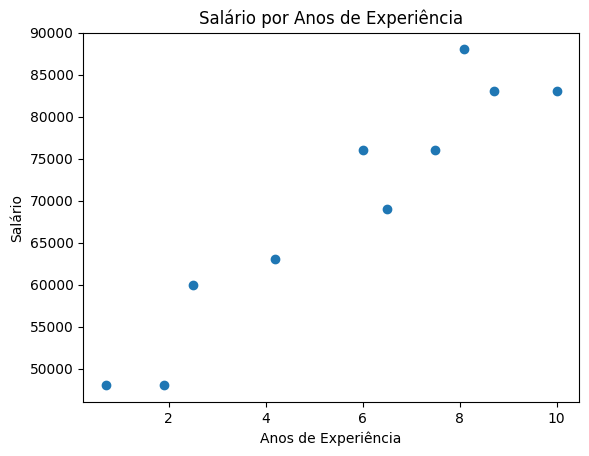

In [13]:
import matplotlib.pyplot as plt

x = [s[1] for s in salaries_and_tenures] # tempo de experiencia
y = [s[0] for s in salaries_and_tenures] # salario

plt.scatter(x, y)
plt.title("Salário por Anos de Experiência")
plt.xlabel("Anos de Experiência")
plt.ylabel("Salário")
plt.show()

In [14]:
# classifica salarios em classes por tenure
def tenure_bucket(tenure):
    if tenure < 2:
        return "less than two"
    elif tenure < 5:
        return "between two and five"
    else:
        return "more than five"

In [15]:
# agrupa salarios em classes
salary_by_tenure_bucket = defaultdict(list)

for salary, tenure in salaries_and_tenures:
    bucket = tenure_bucket(tenure)
    salary_by_tenure_bucket[bucket].append(salary)

salary_by_tenure_bucket

defaultdict(list,
            {'more than five': [83000, 88000, 76000, 69000, 76000, 83000],
             'less than two': [48000, 48000],
             'between two and five': [60000, 63000]})

In [16]:
# media salarial por classe de tenure
average_salary_by_bucket = {
    tenure_bucket: round(sum(salaries) / len(salaries), 1)
    for tenure_bucket, salaries in salary_by_tenure_bucket.items()
}

average_salary_by_bucket

{'more than five': 79166.7,
 'less than two': 48000.0,
 'between two and five': 61500.0}

In [17]:
# em media, quanto a classe mais experiente ganha a mais que a classe menos experiente?
round((average_salary_by_bucket['more than five'] / average_salary_by_bucket['less than two'] -1) *100,1)

64.9

## Tópicos de Interesse

In [18]:
# for user, interest in interests:
#     for word in interest.lower().split():
#         print(word)

words_and_counts = Counter(word
                           for user, interest in interests
                           for word in interest.lower().split()
                           )

# print(words_and_counts)
# print(words_and_counts.most_common()) # retorna todos itens, ordenados pela frequencia
# print(words_and_counts.most_common(2)) # retorna 2 itens mais comuns

for word, count in words_and_counts.most_common():
    if count > 1:
        print(word, count)

big 3
data 3
java 3
python 3
learning 3
hadoop 2
hbase 2
cassandra 2
scikit-learn 2
r 2
statistics 2
regression 2
probability 2
machine 2
neural 2
networks 2


# Capítulo 3 - Visualizando Dados

Página 66-80

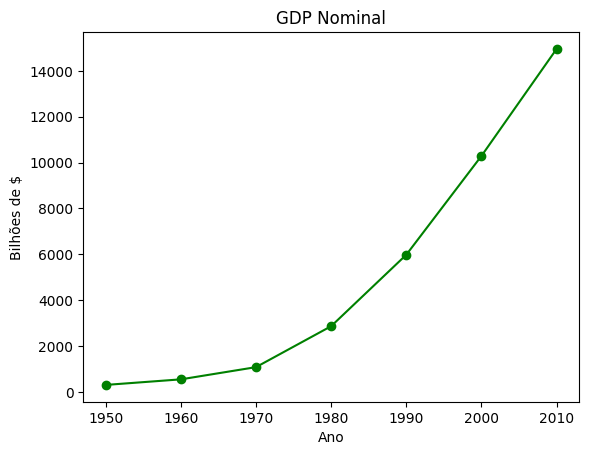

In [19]:
from matplotlib import pyplot as plt

years = [1950, 1960, 1970, 1980, 1990, 2000, 2010]
gdp = [300.2, 543.3, 1075.9, 2862.5, 5979.6, 10289.7, 14958.3]

plt.plot(years, gdp, color='green', marker='o', linestyle='solid')
plt.title("GDP Nominal")
plt.ylabel("Bilhões de $")
plt.xlabel("Ano")
plt.show()

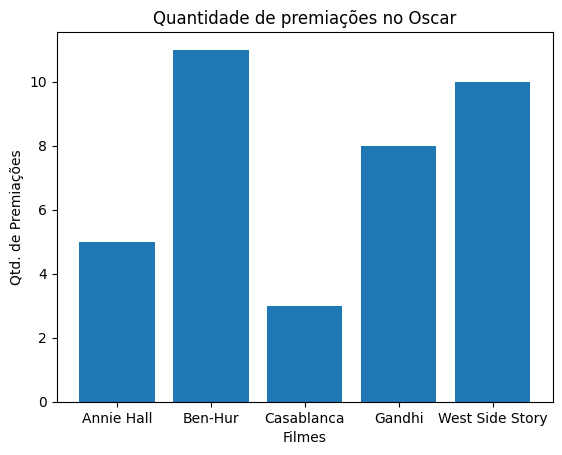

In [20]:
# GRAFICO DE BARRAS
# bom para mostrar como um quantidade varia entre um conjunto de itens
movies = ["Annie Hall", "Ben-Hur", "Casablanca", "Gandhi", "West Side Story"]
num_oscars = [5, 11, 3, 8, 10]

# barras possuem tamalho padrao de 0.8, adicionando 0.1 elas ficam centralizadas
xs = [i + 0.1 for i, _ in enumerate(movies)]

plt.bar(xs, num_oscars)
plt.ylabel("Qtd. de Premiações")
plt.xlabel("Filmes")
plt.title("Quantidade de premiações no Oscar")
plt.xticks([i + 0.1 for i, _ in enumerate(movies)], movies)
plt.show()

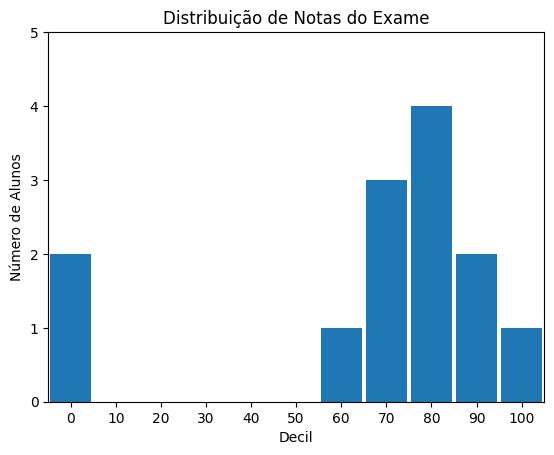

In [21]:
from collections import Counter

grades = [83,95,91,87,70,0,85,82,100,67,73,77,0]
decile = lambda grade: grade // 10 * 10
histogram = Counter(decile(grade) for grade in grades)

plt.bar([x - 0 for x in histogram.keys()],
       histogram.values(),
       9) # larguta da barra

plt.axis([-5, 105, 0, 5]) # limites dos eixos

plt.xticks([10 * i for i in range(11)])
plt.xlabel("Decil")
plt.ylabel("Número de Alunos")
plt.title("Distribuição de Notas do Exame")
plt.show()

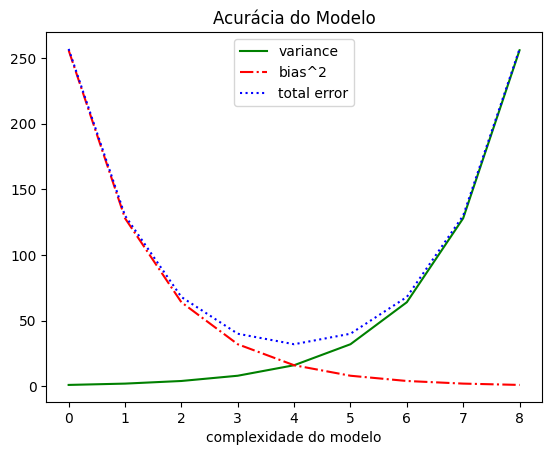

In [22]:
# GRAFICO DE LINHAS
variance = [1,2,4,8,16,32,64,128,256]
bias_squared = [256,128,64,32,16,8,4,2,1]
total_error = [x+y for x, y in zip(variance, bias_squared)]
xs = [i for i, _ in enumerate(variance)]

plt.plot(xs, variance, 'g-', label='variance') # linha verde solida
plt.plot(xs, bias_squared, 'r-.', label='bias^2') # linha vermelha de pontos e linhas
plt.plot(xs, total_error, 'b:', label='total error') # linha azul de pontos

# plt.legend(loc=9) # legenda aparece porque foi atribuido rotulos para cada linha
plt.legend(loc="upper center")
plt.xlabel("complexidade do modelo")
plt.title("Acurácia do Modelo")
plt.show()

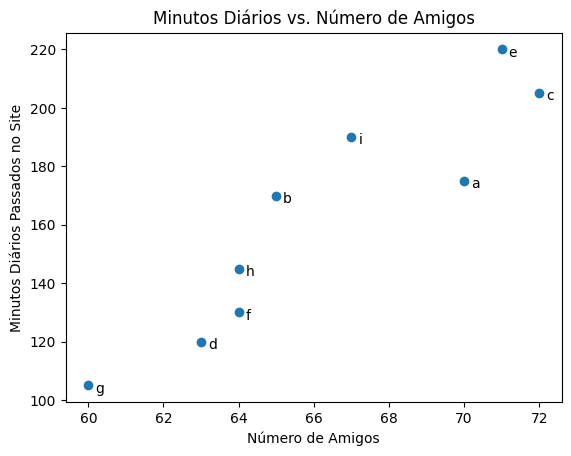

In [23]:
# GRAFICO DE DISPERSAO
friends = [70, 65, 72, 63, 71, 64, 60, 64, 67]
minutes = [175, 170, 205, 120, 220, 130, 105, 145, 190]
labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i']

plt.scatter(friends, minutes)

# anotacao de cada ponto
for label, friend_count, minute_count in zip(labels, friends, minutes):
    plt.annotate(label,
                 xy=(friend_count, minute_count),
                 xytext=(5, -5),
                 textcoords='offset points')

plt.title("Minutos Diários vs. Número de Amigos")
plt.xlabel("Número de Amigos")
plt.ylabel("Minutos Diários Passados no Site")
plt.show()

# Capítulo 4 - Álgebra Linear

Página 81-90

## Vetores

- Possuem intensidade (módulo) e direção
- Podem ser somados juntos para formar novos vetores, desde que tenham a mesma dimensão
- Podem ser multiplicados por um escalar para também formar um novo vetor
- Pontos em um espaço dimensional finito: uma ótima maneira de representar dados numéricos. Ex.:
  - as caracteristicas fisicas de pessoas podem ser representadas por um vetor com as coordenadas $(\text{altura}, \text{peso}, \text{idade})$
  - as notas das provas de uma matéria ao longo do semestre pode ser o vetor $(\text{nota1}, \text{nota2}, \text{nota3}, \text{nota4})$

In [24]:
height_weight_age = [
    170, # altura em cm
    80, # peso em kg
    25 # idade em anos
]
grades = [95, 80, 75, 62] # notas das provas

In [25]:
# somando vetores
def vector_add(v, w):
    return [v_i + w_i for v_i, w_i in zip(v, w)] if len(v) == len(w) else []

vector_add([1, 2], [2, 1])

[3, 3]

In [26]:
vector_add([1, 2], [1, 2, 3])

[]

In [27]:
vector_add_lambda = lambda v, w: [v_i + w_i for v_i, w_i in zip(v, w)] if len(v) == len(w) else []

vector_add_lambda([1, 2], [2, 1])

[3, 3]

In [28]:
vector_add_lambda([1, 2], [1, 2, 3])

[]

In [29]:
# subtraindo vetores
def vector_subtract(v, w):
    return [v_i - w_i for v_i, w_i in zip(v, w)]

vector_subtract([5, 7], [8, 4])

[-3, 3]

In [30]:
# somando lista de vetores
def vector_sum(vectors):
    result = vectors[0]
    for vector in vectors[1:]:
        result = vector_add(result, vector)
    return result

vector_sum([[1, 2], [2, 1]])

[3, 3]

In [31]:
vector_sum([[1, 2], [2, 1], [3, 3]])

[6, 6]

In [44]:
def vector_sum_recursive(vectors):
    return vectors[0] if len(vectors) == 1 else vector_add(vectors[0], vector_sum_recursive(vectors[1:]))

vector_sum_recursive([[1, 2], [2, 1]])

[3, 3]

In [45]:
vector_sum_recursive([[1, 2], [2, 1], [3, 3]])

[6, 6]

In [46]:
vector_sum_recursive([[]])

[]

In [32]:
# escreve funcao de somar multiplos vetores com reduce
from functools import reduce

def vector_sum_reduce(vectors):
    return reduce(vector_add, vectors)

vector_sum_reduce([[1, 2], [2, 1]])

[3, 3]

In [33]:
# como funciona o reduce
numbers = [1, 2, 3, 4, 5]
soma_dois_numeros = lambda x, y: x + y # funcao que recebe dois argumentos
reduce(soma_dois_numeros, numbers) # Calculated as: (((1 + 2) + 3) + 4) + 5 = 15

15

In [34]:
letters = 'abc'
concatena_duas_letras = lambda x, y: x + y # funcao que recebe dois argumentos
reduce(concatena_duas_letras, letters, 'x')

'xabc'

In [35]:
from functools import partial

vector_sum_partial = partial(reduce, vector_add)

vector_sum_partial([[1, 2], [2, 1]])

[3, 3]

In [36]:
# multiplica vetor por escalar
def scalar_multiply(c, v):
    return [c * v_i for v_i in v]

scalar_multiply(2, [1, 2])

[2, 4]

In [37]:
vector_sum([[1, 2], scalar_multiply(-1, [1, 2])])

[0, 0]

In [38]:
# media de uma lista de vetores
def vector_mean(vectors):
    n = len(vectors)
    return scalar_multiply(1/n, vector_sum(vectors))

vector_mean([[1, 2], [2, 1]])

[1.5, 1.5]

In [39]:
# produto escalar de dois vetores
def dot(v, w):
    return sum(v_i * w_i for v_i, w_i in zip(v, w))

dot([1, 2], [2, 1])

4

In [40]:
# soma dos quadrados de um vetor
def sum_of_squares(v):
    return dot(v, v)

sum_of_squares([1, 2])

5

In [41]:
# modulo de um vetor
import math

def magnitude(v):
    return math.sqrt(sum_of_squares(v))

magnitude([3, 4])

5.0

In [42]:
# distancia entre dois vetores
def squared_distance(v, w):
    return sum_of_squares(vector_subtract(v, w))

def distance(v, w):
    return math.sqrt(squared_distance(v, w))

distance([1, 2], [2, 1])

1.4142135623730951

In [43]:
def distance_magnitude(v, w):
    return magnitude(vector_subtract(v, w))

distance_magnitude([1, 2], [2, 1])

1.4142135623730951

## Matrizes

- coleção de números bidimensional
- podemos representar como uma "lista de listas", em que as listas interiores tem o mesmo tamanho
- Se $\text{A}$ é uma matriz, logo $\text{A}_{[i][j]}$ é o elemento da $i$-ésima linha e $j$-ésima da coluna
- Uma matriz $n \space \text{x} \space k$ possui $n$ linhas e $k$ colunas. Podemos pensar em cada linha como um vetor de tamanho $k$ e cada coluna como um vetor de tamanho $n$

In [64]:
A = [[1,2,3],
     [4,5,6]] # matriz 2x3, com 2 linhas e 3 colunas

B = [[1,2],
     [3,4],
     [5,6]] # matriz 3x2, com 3 linhas e 2 colunas

In [67]:
def shape(A):
    num_rows = len(A)
    num_cols = len(A[0]) if A and isinstance(A[0], list) else 0
    return num_rows, num_cols

shape(A)

(2, 3)

In [50]:
def get_row(A, i):
    return A[i]

get_row(A, 1)

[4, 5, 6]

In [51]:
def get_column(A, j):
    return [A_i[j] for A_i in A]

get_column(B, 1)

[2, 4, 6]

In [52]:
def make_matrix(num_rows, num_cols, entry_fn):
    """ retorna matriz num_rows x num_cols, cuja entrada (i,j)th eh entry_fh(i,j) """
    return [[entry_fn(i, j)
             for j in range(num_cols)]
             for i in range(num_rows)]

In [53]:
# matriz identidade 5x5
def is_diagonal(i, j):
    return 1 if i == j else 0

identity_matrix = make_matrix(5, 5, is_diagonal)

identity_matrix

[[1, 0, 0, 0, 0],
 [0, 1, 0, 0, 0],
 [0, 0, 1, 0, 0],
 [0, 0, 0, 1, 0],
 [0, 0, 0, 0, 1]]

### Formas de uso das matrizes

#### Representação de conjuntos de dados

In [88]:
# caracteristicas fisicas de N pessoas, pode ser uma matriz Nx3
data = [[170, 70, 40],
        [165, 85, 26],
        [177, 60, 19],
        [198, 90, 36],
        [163, 80, 32],
        # ...
        ]

#### Representar uma função linear

In [89]:
import numpy as np

def matrix_vector_multiply(matrix, vector):
    """
    Multiplica uma matriz (n x k) por um vetor (k-dimensional),
    resultando em um vetor (n-dimensional).
    """
    n_rows, k_cols = shape(matrix)
    k_elements = len(vector)

    if k_cols != k_elements:
        raise ValueError("O número de colunas da matriz deve ser igual à dimensão do vetor.")

    result_vector = [0 for i in range(n_rows)] # O vetor resultante terá n dimensões

    for i in range(n_rows):
        for j in range(k_cols):
            result_vector[i] += matrix[i][j] * vector[j]

    return result_vector

print(f"Matriz A (n x k):\n{A}")
print(f"Dimensão de A: {shape(A)}")

# Exemplo de um vetor v (k-dimensional), onde k=3
v = [1, 0, -1]

print(f"\nVetor v (k-dimensional): {v}")
print(f"Dimensão de v: {shape(v)}")

# Aplicando a função linear (multiplicação matriz-vetor)
# O resultado será um vetor n-dimensional (2-dimensional neste caso)
result = matrix_vector_multiply(A, v)

print(f"\nResultado da multiplicação A * v (n-dimensional): {result}")
print(f"Dimensão do vetor resultante: {len(result)}")

# Verificação com numpy
numpy_result = np.dot(A, v)
print(f"Resultado com numpy.dot: {numpy_result.tolist()}")

Matriz A (n x k):
[[1, 2, 3], [4, 5, 6]]
Dimensão de A: (2, 3)

Vetor v (k-dimensional): [1, 0, -1]
Dimensão de v: (3, 0)

Resultado da multiplicação A * v (n-dimensional): [-2, -2]
Dimensão do vetor resultante: 2
Resultado com numpy.dot: [-2, -2]


#### Representar relações binárias

In [90]:
friendships

[(0, 1),
 (0, 2),
 (1, 2),
 (1, 3),
 (2, 3),
 (3, 4),
 (4, 5),
 (5, 6),
 (5, 7),
 (6, 8),
 (7, 8),
 (8, 9)]

In [91]:
# usuario 0 1 2 3 4 5 67 7 8 9
#
matriz_friendships = [[0, 1, 1, 0, 0, 0, 0, 0, 0, 0], # usuario 0
                      [1, 0, 1, 1, 0, 0, 0, 0, 0, 0], # usuario 1
                      [1, 1, 0, 1, 0, 0, 0, 0, 0, 0], # usuario 2
                      [0, 1, 1, 0, 1, 0, 0, 0, 0, 0], # usuario 3
                      [0, 0, 0, 1, 0, 1, 0, 0, 0, 0], # usuario 4
                      [0, 0, 0, 0, 1, 0, 1, 1, 0, 0], # usuario 5
                      [0, 0, 0, 0, 0, 1, 0, 0, 1, 0], # usuario 6
                      [0, 0, 0, 0, 0, 1, 0, 0, 1, 0], # usuario 7
                      [0, 0, 0, 0, 0, 0, 1, 1, 0, 1], # usuario 8
                      [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]] # usuario 9

In [92]:
matriz_friendships[0][2] == 1 # True, usuario 0 tem como amigo o usuario 2

True

In [93]:
matriz_friendships[0][8] == 1 # False, usuario 0 nao tem como amigo o usuario 8

False

In [94]:
for indice, is_friend in enumerate(matriz_friendships[5]):
    print(indice, is_friend)

0 0
1 0
2 0
3 0
4 1
5 0
6 1
7 1
8 0
9 0


In [95]:
friends_of_5 = [i for i, is_friend in enumerate(matriz_friendships[5]) if is_friend]
friends_of_5

[4, 6, 7]